In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        fullpath = os.path.join(dirname, filename) 
        print(fullpath)

        if filename == "train.csv":
            trainDS = pd.read_csv(fullpath)
            trainDS_unprocessed =  pd.read_csv(fullpath)
        if filename == "test.csv":
            testDS = pd.read_csv(fullpath)
        if filename == "Fertilizer Prediction.csv":
            original = pd.read_csv(fullpath)
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e6/sample_submission.csv
/kaggle/input/playground-series-s5e6/train.csv
/kaggle/input/playground-series-s5e6/test.csv
/kaggle/input/fertilizer-prediction/Fertilizer Prediction.csv


In [2]:
## FOR TESTING
# Get top 64 values
#trainDS = trainDS.head(256)

In [3]:
# import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

label_encoder_list = {} # Define label encoding list for later un-label encoding
scaler = MinMaxScaler() # Define minmax scalar
label_encoder_out = LabelEncoder()

# Split features and labaels
if "Fertilizer Name" in trainDS:
    y_train = trainDS["Fertilizer Name"]
    if "id" in trainDS.columns:
        x_train = trainDS.drop(columns = "Fertilizer Name")
        x_train = trainDS.drop(columns = ["id","Fertilizer Name"])
        testDS = testDS.drop(columns = "id")
        x_test = testDS
    else:
        #x_test = testDS
        print("Id not in column")

# Get all columns before we start breakin stuff
columns_train = x_train.columns

# Encoding

x_train_encoded = pd.DataFrame(index=x_train.index)
x_test_encoded = pd.DataFrame(index=x_test.index)

categorical_cols = x_train.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    le = LabelEncoder()
    x_train_encoded[col] = le.fit_transform(x_train[col])
    x_test_encoded[col] = le.transform(x_test[col])
    label_encoder_list[col] = le # Add to label encoder list 
    print("Double check: Encoded column:",col,". Minimum: ", min(x_train[col]), ". Max: ",max(x_train[col]))

y_train_encoded = label_encoder_out.fit_transform(y_train)
y_train_encoded = pd.DataFrame(y_train_encoded)

Double check: Encoded column: Soil Type . Minimum:  Black . Max:  Sandy
Double check: Encoded column: Crop Type . Minimum:  Barley . Max:  Wheat


In [4]:
numerical_cols = columns_train.difference(categorical_cols)

print("Columns to scale: ", numerical_cols)

x_train_transformed = pd.DataFrame(index=x_train.index)
x_test_transformed = pd.DataFrame(index=x_test.index)


## Scaling
for col in numerical_cols:
    x_train_transformed[col] = scaler.fit_transform(x_train[[col]].values)   
    x_test_transformed[col] = scaler.fit_transform(x_test[[col]].values)
    
    print("Double check: Encoded column:",col,". Minimum: ", min(x_train_transformed[col]), ". Max: ",max(x_train_transformed[col]))
    
# Convert everything to floats
x_train_transformed = x_train_transformed.astype(float)
y_train_encoded = y_train_encoded.astype(float)

x_test_transformed = x_test_transformed.astype(float)

# Recombine dataframes
x_train = pd.concat([x_train_transformed, x_train_encoded], axis=1)
x_test = pd.concat([x_test_transformed, x_test_encoded], axis=1)

# Debug - print sizing
print("X train shape: ", x_train.shape)
print("Y train shape: ", y_train_encoded.shape)

# Train test split
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train, y_train_encoded, 
    test_size=0.2,    
    random_state=42,  
    stratify=y_train 
)

x_train_from_split = x_train
y_train_from_split = y_train
y_valid_from_split = y_valid

Columns to scale:  Index(['Humidity', 'Moisture', 'Nitrogen', 'Phosphorous', 'Potassium',
       'Temparature'],
      dtype='object')
Double check: Encoded column: Humidity . Minimum:  0.0 . Max:  1.0
Double check: Encoded column: Moisture . Minimum:  0.0 . Max:  1.0
Double check: Encoded column: Nitrogen . Minimum:  0.0 . Max:  0.9999999999999999
Double check: Encoded column: Phosphorous . Minimum:  0.0 . Max:  1.0
Double check: Encoded column: Potassium . Minimum:  0.0 . Max:  1.0
Double check: Encoded column: Temparature . Minimum:  0.0 . Max:  1.0000000000000002
X train shape:  (750000, 8)
Y train shape:  (750000, 1)


In [5]:
x_train_df = pd.DataFrame(x_train, columns=columns_train)
y_train_df = pd.DataFrame(y_train)

x_valid_df = pd.DataFrame(x_valid, columns=columns_train)
y_valid_df = pd.DataFrame(y_valid)

x_test = pd.DataFrame(x_test, columns=columns_train)

In [6]:
# Burn it down!
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Convert to tensors
x_train = torch.tensor(x_train_df.values, dtype=torch.float32)
y_train = torch.tensor(y_train_df.values, dtype=torch.float32)

x_valid = torch.tensor(x_valid_df.values, dtype=torch.float32)
y_valid = torch.tensor(y_valid_df.values, dtype=torch.float32)

x_test = torch.tensor(x_test.values, dtype=torch.float32)

In [7]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train, y_train)
valid_dataset = TensorDataset(x_valid, y_valid)
test_dataset = TensorDataset(x_test)

print(len(train_dataset))

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

last_batch_x, last_batch_y = None, None
for batch_x, batch_y in train_loader:
    last_batch_x, last_batch_y = batch_x, batch_y

print("Last batch size:", last_batch_x.shape[0])  # batch size (number of samples)

600000
Last batch size: 16


In [8]:
# you know tha drill
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [9]:
class fert(nn.Module):
    def __init__(self, num_cols, batch_size, thickness, num_classes, debug_verbose = False):
        super(fert,self).__init__()
        self.debug_verbose = debug_verbose
        self.num_cols = num_cols
        self.batch_size = batch_size
        self.thickness = thickness
        self.num_classes = num_classes

        # Layers 
        self.activation = torch.nn.ReLU()
        self.bn = torch.nn.BatchNorm1d(num_cols)

        hidden_dim = int(self.thickness * self.batch_size)
        self.ln1 = nn.Linear(num_cols, hidden_dim)
        
        self.to_out = torch.nn.Linear(int(self.thickness * self.batch_size), self.batch_size * self.num_classes)

        self.output = torch.nn.Linear(self.batch_size * self.num_classes, self.num_classes)
    
    def apply(self, layer, x, name=""):
        x = layer(x)
        if self.debug_verbose:
            print(f"{name} output shape: {x.shape}")
        return x

    def forward(self, x):
        if self.debug_verbose:
            print(f"Input size before BN: {x.shape}")
        
        x = self.apply(self.bn, x, "BatchNorm")
        x = self.apply(self.ln1, x, "Layer 1")
        x = self.apply(self.activation, x, "Activation 1")
        x = self.apply(self.to_out, x, "To Out")
        x = self.apply(self.activation, x, "Activation 2")
        x = self.apply(self.output, x, "Final Output")
        
        return x


In [10]:
# Model initialization
num_cols = x_train.shape[1]
thickness = 64
num_classes = trainDS["Fertilizer Name"].nunique()
debug_verbose = False
num_epochs = 5
learning_rate = 0.1

print("Num cols: ", num_cols)
print("Num classes: ", num_classes)
print("Thickness: ", thickness)
print("Debug verbose: ", debug_verbose)
print("Num epochs: ", num_epochs)
print("Learning rate: ",learning_rate)

model = fert(num_cols = num_cols, batch_size = batch_size, thickness = thickness, num_classes = num_classes, debug_verbose = debug_verbose)

Num cols:  8
Num classes:  7
Thickness:  64
Debug verbose:  False
Num epochs:  5
Learning rate:  0.1


In [11]:
# Custom loss function
import torch
import torch.nn as nn
import torch.nn.functional as F

class Top3PenaltyLoss(nn.Module):
    def __init__(self, base_loss_fn=None, penalty_weight=1.0):
        super().__init__()
        # base_loss_fn is typically nn.CrossEntropyLoss()
        self.base_loss_fn = base_loss_fn if base_loss_fn else nn.CrossEntropyLoss()
        self.penalty_weight = penalty_weight

    def forward(self, outputs, targets):
        """
        outputs: [batch_size, num_classes] (logits, NOT probabilities)
        targets: [batch_size] (class indices)
        """
        
        # 1. Base classification loss (CrossEntropyLoss expects logits)
        base_loss = self.base_loss_fn(outputs, targets)

        # 2. Compute softmax to get class probabilities
        probs = F.softmax(outputs, dim=1)  # shape [batch_size, num_classes]

        # 3. Get top 3 probabilities and their indices per sample 
        _, top3_pred = torch.topk(outputs, k=3, dim=1)  # shape: [batch_size, 3]

        # 4. Define your custom penalty based on top 3 probs
        # Example penalty: sum of the top 3 probs (encourage spread or sharpness)
        # You can replace this with any function you want
        map3_scores = torch.zeros(batch_size, device=outputs.device)
        
        for i in range(batch_size):
            true_label = targets[i]
            preds = top3_pred[i]
            if true_label in preds:
                rank = (preds == true_label).nonzero(as_tuple=True)[0].item() + 1  # rank is 1-based
                map3_scores[i] = 1.0 / rank  # precision at rank

        mean_map3 = map3_scores.mean()

        # Since higher MAP@3 is better, if you want to use as penalty,
        # you might want to subtract it or do 1 - mean_map3
        penalty = 1 - mean_map3  # smaller is better

        # Total loss
        total_loss = base_loss + self.penalty_weight * penalty

        return total_loss


# Map3
def mapk(actual, predicted, k=3):
    """
    Computes the mean average precision at k.
    actual: tensor of shape [batch_size]
    predicted: tensor of shape [batch_size, num_classes]
    """
    predicted_topk = torch.topk(predicted, k, dim=1).indices.cpu().numpy()
    actual = actual.cpu().numpy().reshape(-1, 1)

    score = 0.0
    for act, pred in zip(actual, predicted_topk):
        if act in pred:
            score += 1.0 / (np.where(pred == act[0])[0][0] + 1)
    return score / len(actual)

In [12]:
#Training 
def train_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_map3": []
    }
    
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch_features, batch_labels in train_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)  # Move data to GPU
            optimizer.zero_grad()  # Clear gradients
            outputs = model(batch_features)  # Forward pass
            loss = loss_fn(outputs.squeeze(), batch_labels.squeeze().long())  # Compute loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update weights
            train_loss += loss.item()

        train_loss /= len(train_loader)
        history["train_loss"].append(train_loss)

        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for batch_features, batch_labels in val_loader:
                batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)  # Move data to GPU
                outputs = model(batch_features)  # Forward pass
                loss = loss_fn(outputs, batch_labels.squeeze().long())  # Compute loss
                val_loss += loss.item()
                all_preds.append(outputs)
                all_targets.append(batch_labels.squeeze())
                
        val_loss /= len(val_loader)
        history["val_loss"].append(val_loss)
        
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)


        print("all_preds shape:", all_preds.shape)       # should be [batch_size, num_classes]
        print("all_targets shape:", all_targets.shape)   # should be [batch_size]

        
        predicted_classes = torch.argmax(all_preds, dim=1)
        accuracy = (predicted_classes == all_targets).sum().item() / len(all_targets)
        history["val_accuracy"].append(accuracy)

        map3_score = mapk(all_targets, all_preds, k=3)
        history["val_map3"].append(map3_score)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Accuracy={accuracy:.4f}, MAP@3={map3_score:.4f}")

    return model, history

loss_fn = Top3PenaltyLoss(base_loss_fn=nn.CrossEntropyLoss(), penalty_weight=0.5)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
model, history = train_model(model, train_loader, valid_loader, loss_fn, optimizer, num_epochs)

all_preds shape: torch.Size([150000, 7])
all_targets shape: torch.Size([150000])
Epoch 1/5: Train Loss=1.9629, Val Loss=1.9816, Accuracy=0.1482, MAP@3=0.2652
all_preds shape: torch.Size([150000, 7])
all_targets shape: torch.Size([150000])
Epoch 2/5: Train Loss=1.9572, Val Loss=1.9601, Accuracy=0.1479, MAP@3=0.2734
all_preds shape: torch.Size([150000, 7])
all_targets shape: torch.Size([150000])
Epoch 3/5: Train Loss=1.9573, Val Loss=1.9543, Accuracy=0.1479, MAP@3=0.2605
all_preds shape: torch.Size([150000, 7])
all_targets shape: torch.Size([150000])
Epoch 4/5: Train Loss=1.9570, Val Loss=1.9501, Accuracy=0.1518, MAP@3=0.2690
all_preds shape: torch.Size([150000, 7])
all_targets shape: torch.Size([150000])
Epoch 5/5: Train Loss=1.9572, Val Loss=1.9532, Accuracy=0.1518, MAP@3=0.2781


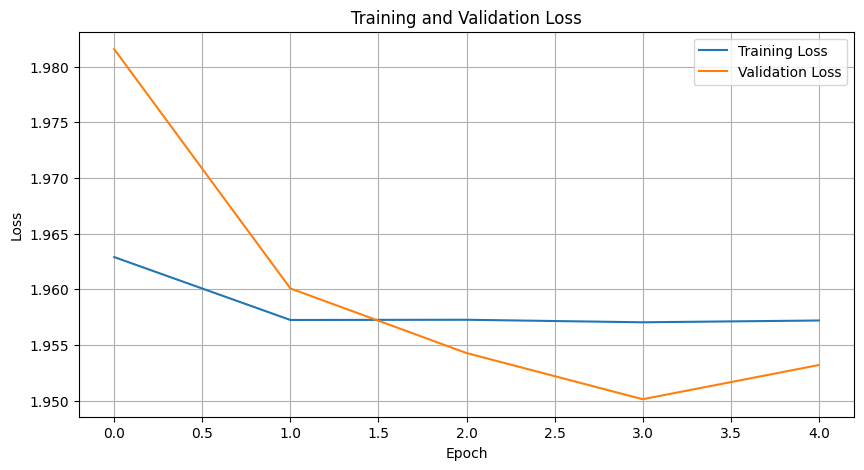

In [13]:
import matplotlib.pyplot as plt
# ---- Plotting Training and Validation Loss ----
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Evaluation Function ----
def evaluate_model(model, data_loader, dataset_name=""):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        if dataset_name == "Test":
            for batch_features in data_loader:
                batch_features = batch_features[0].to(device)
                outputs = model(batch_features)
                top3 = torch.topk(outputs, k=3, dim=1).indices.cpu().numpy()
                all_preds.extend(top3)
            return all_preds, None
        else:
            for batch_features, batch_labels in data_loader:
                batch_features = batch_features.to(device)
                outputs = model(batch_features)
                top3 = torch.topk(outputs, k=3, dim=1).indices.cpu().numpy()
                all_preds.extend(top3)
                all_labels.extend(batch_labels.numpy())
            return all_preds, all_labels


# Evaluate on train, valid, and test
train_preds, train_labels = evaluate_model(model, train_loader, "Train")
valid_preds, valid_labels = evaluate_model(model, valid_loader, "Validation")
test_preds, _ = evaluate_model(model, test_loader, "Test")




# Continue by un-scaling the output on test and making submission

In [14]:
# ---- Convert predictions to DataFrame and Save ----
def write_predictions_to_csv(preds, labels=None, filename="results.csv", index_to_label=None, original_labels_df=None, x_train_from_split = None):
    rows = []
    for i, pred in enumerate(preds):
        row = {
            "Top1": index_to_label[pred[0]] if index_to_label else pred[0],
            "Top2": index_to_label[pred[1]] if index_to_label else pred[1],
            "Top3": index_to_label[pred[2]] if index_to_label else pred[2]
        }
        
        if labels is not None:
            row["Label from train_labels"] = index_to_label[labels[i].item()] if index_to_label else labels[i]
        if original_labels_df is not None:
            row["Label from original_labels_df"] =  index_to_label[original_labels_df.iloc[i, 0]] if index_to_label else original_labels_df.iloc[i, 0]
        if x_train_from_split is not None:
            row["ID"] = x_train_from_split.index[i]
            
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(filename, index=False)
    print(f"Saved predictions to {filename}")

    # Add ids to test dataset
    if filename == "test_results.csv":
        return df

index_to_label = {i: label for i, label in enumerate(label_encoder_out.classes_)}

print(index_to_label)

write_predictions_to_csv(train_preds, train_labels, "train_results.csv", index_to_label, y_train_from_split, x_train_from_split)
write_predictions_to_csv(valid_preds, valid_labels, "valid_results.csv", index_to_label, y_valid_from_split)
test_preds = write_predictions_to_csv(test_preds, None, "test_results.csv",index_to_label)

{0: '10-26-26', 1: '14-35-14', 2: '17-17-17', 3: '20-20', 4: '28-28', 5: 'DAP', 6: 'Urea'}
Saved predictions to train_results.csv
Saved predictions to valid_results.csv
Saved predictions to test_results.csv


In [15]:
submission = test_preds
submission.head(5)

if "Top1" in submission.columns:
    submission["Fertilizer Name"] = submission[["Top1", "Top2", "Top3"]].apply(
        lambda row: ' '.join(
            str(item) if not isinstance(item, (list, np.ndarray)) else ' '.join(map(str, item))
            for item in row
        ),
        axis=1
    )
    
    submission.drop(["Top1","Top2","Top3"],axis = 1, inplace = True)

submission.to_csv("submission.csv");